In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("surface_wqi_pred.csv")

df.head()

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,0.3,9.0,NaN,NaN,500,NaN,NaN,63.789474,Medium,NaN
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,0.3,9.0,NaN,NaN,500,NaN,NaN,57.894737,Medium,NaN
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,0.5,11.0,NaN,5.0,500,NaN,NaN,54.035088,Medium,NaN
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,0.0,5.0,NaN,NaN,1200,300.0,NaN,65.101754,Medium,NaN
4,Brahma Sarovar(Site 2) Surface Water,2017,6.20,NaN,2.30,634,13.0,90.0,13.55,86.2,...,0.3,15.0,NaN,NaN,1300,300.0,NaN,80.631579,Good,68.382807


In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Site                            42 non-null     object 
 1   Year                            42 non-null     int64  
 2   pH                              42 non-null     float64
 3   Odour                           0 non-null      float64
 4   Turbidity                       42 non-null     float64
 5   Conductivity                    42 non-null     int64  
 6   Chloride (ppm)                  42 non-null     float64
 7   Sulphates(ppm)                  42 non-null     float64
 8   Iron (ppm)                      42 non-null     float64
 9   COD(ppm)                        42 non-null     float64
 10  BOD(ppm)                        42 non-null     float64
 11  DO(ppm)                         42 non-null     float64
 12  Lead(ppm)                       0 non-

Site                               0
Year                               0
pH                                 0
Odour                             42
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Lead(ppm)                         42
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Fluorides(ppm)                    30
Phosphates(ppm)                   41
Total Bacterial Count (cfu/ml)     0
Total Fungal Count (cfu/ml)       18
Pesticide (µg/l)                  42
WQI                                0
WQI_Class                          0
WQI_Pred                          29
dtype: int64

In [6]:
#REMOVE NON-NUMERIC COLUMNS
df = df.drop(columns=["WQI_Pred"], errors="ignore")

if "Hotspot" in df.columns:
    df["Hotspot"] = df["Hotspot"].astype(int)

In [7]:
#FEATURE SELECTION
X = df.select_dtypes(include="number").drop(columns=["WQI"])
y = df["WQI"]

In [21]:
df.shape

(42, 22)

In [22]:
#Remove columns that are completely empty; Odour,lead, pesticides
X = X.dropna(axis=1, how='all')

In [29]:
print(X.shape)

(42, 16)


In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [31]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
#SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
#DEFINE MODELS
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVM": SVR(kernel="rbf", C=100, gamma=0.1),
    "XGBoost": XGBRegressor(random_state=42)
}

In [34]:
#NSE FUNCTION
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) /
                np.sum((y_true - np.mean(y_true))**2))

In [35]:
#TRAIN MODELS+ METRICS
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    nse_val = nse(y_test, y_pred)

    results.append([name, r2, rmse, mae, nse_val])

In [36]:
#K FOLD CROSS VALIDATION
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

final_results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    nse_val = nse(y_test, y_pred)

    cv5 = cross_val_score(model, X, y, cv=kf5, scoring="r2")
    cv10 = cross_val_score(model, X, y, cv=kf10, scoring="r2")

    final_results.append([
        name,
        r2,
        rmse,
        mae,
        nse_val,
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])

In [37]:
columns = [
"Model",
"R²",
"RMSE",
"MAE",
"NSE",
"5-Fold R²",
"10-Fold R²"
]

results_df = pd.DataFrame(final_results, columns=columns)

results_df.sort_values(by="R²", ascending=False)

,Model,R²,RMSE,MAE,NSE,5-Fold R²,10-Fold R²
3,SVM,0.918021,5.078726,4.287494,0.918021,-0.269 ± 0.327,-0.453 ± 0.553
4,XGBoost,0.858457,6.673423,4.263250,0.858457,0.777 ± 0.119,0.731 ± 0.323
1,Gradient Boosting,0.855581,6.740879,4.648753,0.855581,0.856 ± 0.095,0.778 ± 0.331
2,Decision Tree,0.793690,8.056851,5.915789,0.793690,0.525 ± 0.354,0.345 ± 0.705
0,Random Forest,0.715181,9.466499,7.297380,0.715181,0.774 ± 0.141,0.747 ± 0.236


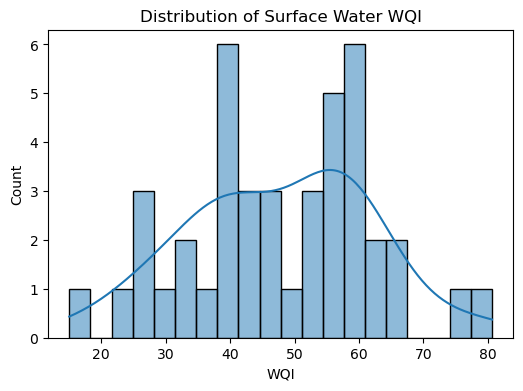

In [38]:
#WQI DISTRIBUTION PLOT
#shows the dataset behaviour
plt.figure(figsize=(6,4))
sns.histplot(df["WQI"], bins=20, kde=True)
plt.title("Distribution of Surface Water WQI")
plt.xlabel("WQI")
plt.show()

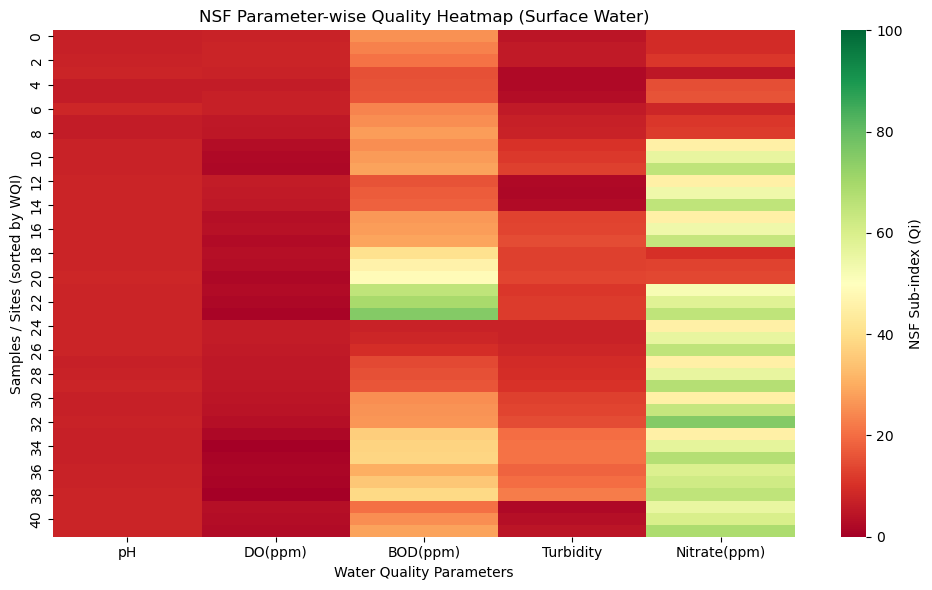

In [44]:
#HEATMAP PLOTTING
qi_cols = [
    "pH",
    "DO(ppm)",
    "BOD(ppm)",
    "Turbidity",
    "Nitrate(ppm)",
    #"TDS",
]

heatmap_data = df[qi_cols]

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",     # red = bad quality, green = good
    vmin=0,
    vmax=100,
    cbar_kws={"label": "NSF Sub-index (Qi)"}
)

plt.title("NSF Parameter-wise Quality Heatmap (Surface Water)")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Samples / Sites (sorted by WQI)")
plt.tight_layout()
plt.show()

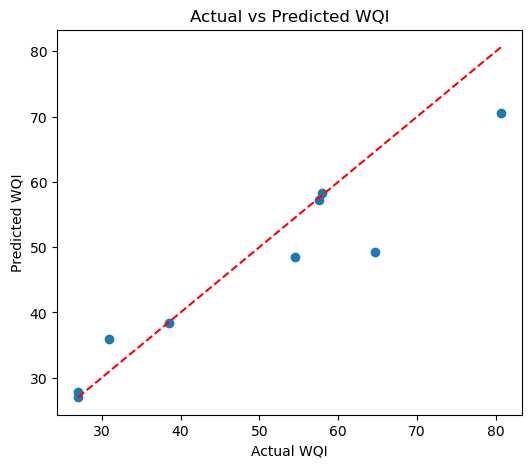

In [39]:
#ACTUAL VS PREDICTED PLOT
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
'r--'
)

plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")

plt.title("Actual vs Predicted WQI")

plt.show()

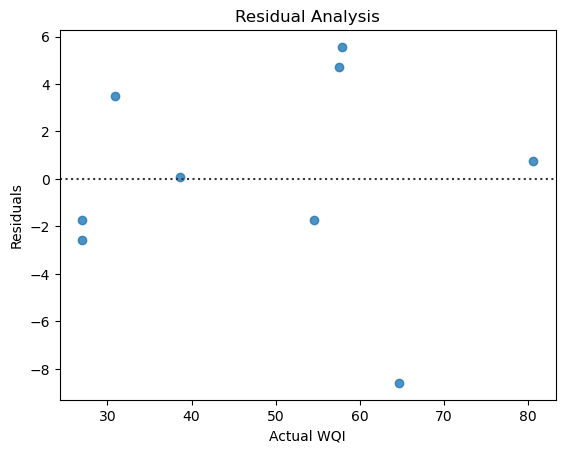

In [40]:
#RESIDUAL PLOT
#Checks model errors
sns.residplot(x=y_test, y=y_pred)

plt.xlabel("Actual WQI")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

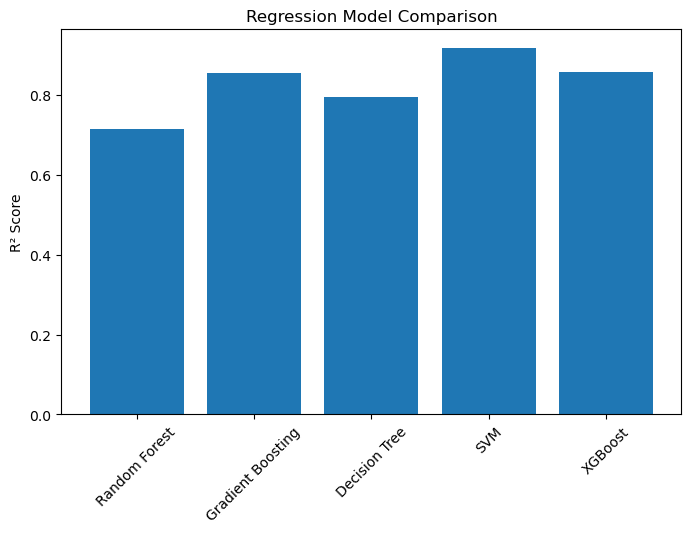

In [43]:
#MODEL COMPEROSSION GRAPH

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R²"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.show()

In [45]:
#SHAP ANALYSIS
import shap
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

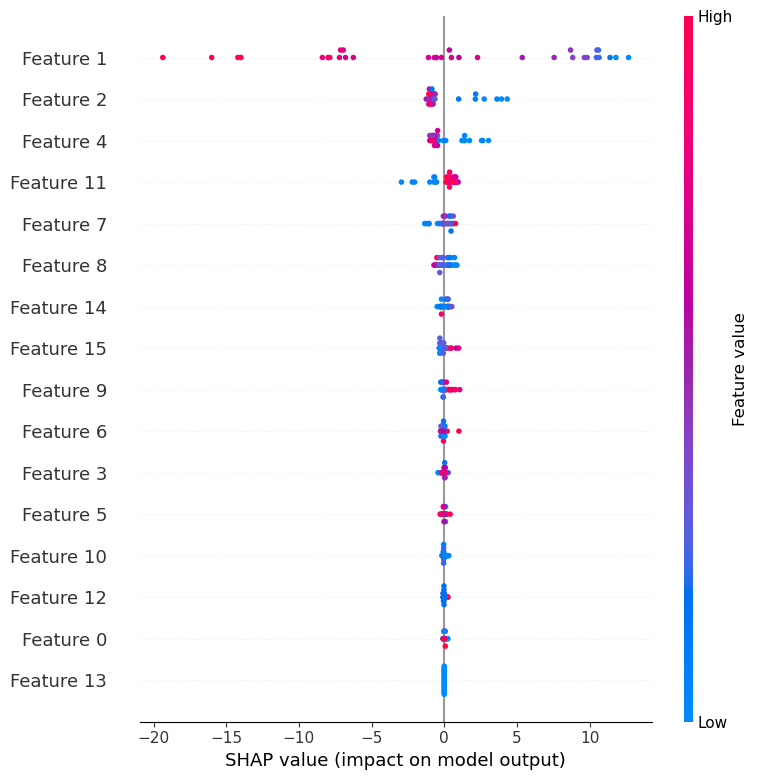

In [46]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)
#PLOT
shap.summary_plot(shap_values, X_train)
#Red - high feature value
#Blue - low feature value